## What This Notebook Covers

By the end of this notebook, you will have:

- loaded and checked a prepared spatial transcriptomics dataset
- preprocessed the data into a STEER-ready representation
- run the first training stage to learn a stable cell-state representation
- derive kinetic priors and use them in the second training stage for kinetic learning
- generated velocity-related outputs and spatial visualizations

This notebook is designed to clarify the main workflow, not to expose every optional feature.

## Expected Input

The recommended input is an `AnnData` object with the following structure:

- `adata.layers['spliced']`: required
- `adata.layers['unspliced']`: required
- `adata.obs_names` and `adata.var_names`: required
- `adata.obsm['X_spatial']`: required for the spatial workflow used here

This quick start uses the demo dataset included in the repository.

In [1]:
import os
import random
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scanpy as sc
import scvelo as scv
import seaborn as sns
import torch
import torch.backends.cudnn as cudnn

import steer
from steer.prior.prior import PriorInferenceManager

warnings.filterwarnings("ignore")
%matplotlib inline

print("=== STEER Quick Start Environment ===")
print(f"PyTorch version: {torch.__version__}")
print(f"Scanpy version: {sc.__version__}")
print(f"scVelo version: {scv.__version__}")
print(f"STEER version: {getattr(steer, '__version__', 'dev build')}")
print("====================================")

=== STEER Quick Start Environment ===
PyTorch version: 2.8.0+cu128
Scanpy version: 1.10.2
scVelo version: 0.3.3
STEER version: 2.2.2


## Configuration

This section defines the dataset path, output directory, random seed, and a small set of core parameters.
The defaults below are suitable for running the bundled example and provide a reasonable starting point for most users.

In [2]:
class Config:
    # Data
    data_name = "bilinear"
    input_dir = "../../tutorials/demo_data"
    result_dir = "../../tutorials/results"
    seed = 2026

    # Model and graph settings
    expert = 3  # Temporary default; update after preprocessing with steer.estimate_expert_number
    smooth_neigh = 30
    spatial_neighbors = 8
    npc = 30

    # Training settings
    pretrain_epochs = 500
    finetune_epochs = 5000

    # Advanced settings
    graph = "union"
    corr_mode = "u"
    neighbor_metric = "cosine"
    use_us = True
    use_filter = False
    fine_method = "hierarchical"
    target_size = 300

cfg = Config()

INPUT_FILE = os.path.join(cfg.input_dir, f"{cfg.data_name}.h5ad")
RESULT_PATH = os.path.join(cfg.result_dir, f"{cfg.data_name}_quickstart")
os.makedirs(RESULT_PATH, exist_ok=True)

print(f"Input file: {INPUT_FILE}")
print(f"Output directory: {RESULT_PATH}")


Input file: ../../tutorials/demo_data/bilinear.h5ad
Output directory: ../../tutorials/results/bilinear_quickstart


## How To Choose Key Parameters

A few parameters play the key roles in the model behavior:

- `smooth_neigh`: the number of neighbors used for smoothing. If the data quality is poor or noisy, increasing this value can help stabilize the signal. In practice, `30` or `100` often works well in many settings.
- `spatial_neighbors`: the number of neighbors used in the spatial graph. For relatively coarse-resolution data, `8` is often enough. For high-resolution data, increasing it to around `30` can improve robustness to local noise.
- `use_filter`: whether to filter genes before the kinetic-learning stage. `False` means the model keeps the full gene set after basic QC. This is often convenient for an initial run. If enabled, STEER uses its prior-inference strategy to retain genes that are more suitable for kinetic inference.
- `expert`: the number of kinetic experts. In this quick start, we keep a temporary default in `cfg.expert` and then estimate a better value from the processed embedding immediately after `Basic Preprocessing`.


## Reproducibility And Device Setup

To keep the tutorial reproducible, we fix the random seed before loading data and training the model.
The notebook will automatically use a GPU if one is available.

In [3]:
def setup_seed(seed: int) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    cudnn.deterministic = True
    cudnn.benchmark = False

setup_seed(cfg.seed)
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda:0


## Load The Demo Dataset

We begin by loading the bundled demo dataset and checking whether the required layers and spatial coordinates are present.
These checks are useful when you later replace the demo file with your own data.

In [4]:
adata = sc.read_h5ad(INPUT_FILE)

print(adata)
print("\nAvailable layers:", list(adata.layers.keys()))
print("Available obsm keys:", list(adata.obsm.keys()))
print(f"Number of cells: {adata.n_obs}")
print(f"Number of genes: {adata.n_vars}")

required_layers = ["spliced", "unspliced"]
missing_layers = [layer for layer in required_layers if layer not in adata.layers]
if missing_layers:
    raise ValueError(f"Missing required layers: {missing_layers}")
if "X_spatial" not in adata.obsm:
    raise ValueError("This quick start expects spatial coordinates in adata.obsm['X_spatial'].")

AnnData object with n_obs × n_vars = 3000 × 500
    obs: 'true_time'
    var: 'true_alpha', 'true_beta', 'true_gamma', 'true_ton', 'true_toff', 'repressive_genes'
    obsm: 'X_spatial', 'true_spatial_velocity', 'velocity_spatial'
    layers: 'spliced', 'true_rho', 'unspliced'

Available layers: ['spliced', 'true_rho', 'unspliced']
Available obsm keys: ['X_spatial', 'true_spatial_velocity', 'velocity_spatial']
Number of cells: 3000
Number of genes: 500


## Basic Preprocessing

`scvelo.pp.filter_and_normalize` prepares the input for downstream velocity modeling.
After that, `steer.preprocess_anndata_spatial` builds the STEER-ready dataframe, adjacency matrix, and processed `AnnData` object used by the graph-based model.

In [5]:
scv.pp.filter_and_normalize(adata, min_shared_counts=None, n_top_genes=None, enforce=True)

df, adjacency_matrix, adata = steer.preprocess_anndata_spatial(
    adata,
    npc=cfg.npc,
    NUM_AD_NEIGH=30,
    spatial_neighbors=cfg.spatial_neighbors,
    SMOOTH_NEIGH=cfg.smooth_neigh,
    moments_adj=True,
    combine_mode=cfg.graph,
    neighbor_metric=cfg.neighbor_metric,
    spatial_key="X_spatial",
    use_us=cfg.use_us,
)

print(df.head())
print("\nAdjacency matrix shape:", adjacency_matrix.shape)

Normalized count data: X, spliced, unspliced.
Logarithmized X.


/nvme/users/liuzhy/miniconda3/envs/steer_dev/lib/python3.10/site-packages/scvelo/preprocessing/utils.py:705: DeprecationWarning: `log1p` is deprecated since scVelo v0.3.0 and will be removed in a future version. Please use `log1p` from `scanpy.pp` instead.
  log1p(adata)


computing moments based on connectivities
    finished (0:00:00) --> added 
    'Ms' and 'Mu', moments of un/spliced abundances (adata.layers)
  cellID gene_name  unsplice    splice  orig_unsplice  orig_splice        Mu  \
0      0         0  0.120764  0.151685            0.0     0.283035  0.038810   
1      1         0  0.224775  0.086827            0.0     0.044122  0.072236   
2      2         0  0.412140  0.225812            0.0     0.093380  0.132449   
3      3         0  0.529100  0.161109            0.0     0.000000  0.170036   
4      4         0  0.512205  0.116279            0.0     0.024226  0.164607   

         Ms  
0  0.012870  
1  0.007367  
2  0.019159  
3  0.013669  
4  0.009866  

Adjacency matrix shape: (3000, 3000)


## Estimate The Expert Number

Expert-number selection should use the processed representation from `Basic Preprocessing`. With the default quick-start setting `use_us=True`, the relevant embedding is stored in `adata.obsm["X_pca_combined"]`.

The helper below keeps the workflow in Python, runs `mclust` through STEER, saves the entropy elbow figure, and returns a recommended `expert` value.


fitting ...
  |                                                                      |   0%

/nvme/users/liuzhy/miniconda3/envs/steer_dev/lib/python3.10/site-packages/rpy2/robjects/numpy2ri.py:241: DeprecationWarning: The global conversion available with activate() is deprecated and will be removed in the next major release. Use a local converter.
  warnings.warn('The global conversion available with activate() '


  |======================================================================| 100%
Selected expert number: 3
Entropy elbow figure: ../../tutorials/results/bilinear_quickstart/Cluster_Number_Selection.png


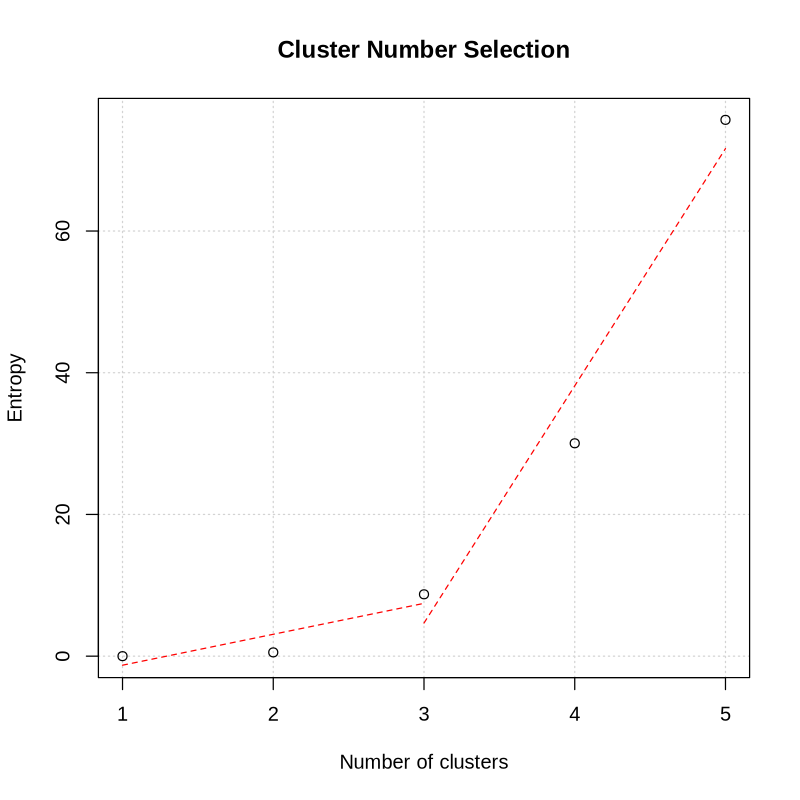

In [6]:
from IPython.display import Image, display

expert_result = steer.estimate_expert_number(
    adata,
    candidate_range=range(2, 6),
    used_obsm="X_pca_combined",
    save_path=RESULT_PATH,
)

cfg.expert = expert_result["recommended_expert"]
print(f"Selected expert number: {cfg.expert}")

if expert_result["figure_path"] is not None:
    print(f"Entropy elbow figure: {expert_result['figure_path']}")
    display(Image(filename=expert_result["figure_path"]))


## Prepare PyTorch Geometric Inputs

STEER trains on a graph representation of the dataset.
This step packages the processed dataframe and adjacency matrix into the PyTorch Geometric format expected by the training functions.

In [7]:
dataset = steer.preload_datasets_all_genes_anndata(df=df, MODEL_MODE="pretrain", adata=adata)
pyg_data = steer.create_pyg_data(dataset, adjacency_matrix, normalize=True)

print(pyg_data)

Data(x=[3000, 1000], edge_index=[2, 143781], type_features=[3000, 500], orig_features=[3000, 1000], cell_ids=[3000], adj=[3000, 3000])


## Step 1: First-Stage Training

The first training stage learns an initial latent representation, expert assignments, and cell-state structure.
This stage provides the geometric foundation used by the later kinetic-learning stage.

In [8]:
result_adata = steer.model_training_share_neighbor_adata(
    device=device,
    device2=device,
    pyg_data=pyg_data,
    MODEL_MODE="pretrain",
    adata=adata,
    NUM_LOSS_NEIGH=30,
    corr_mode=cfg.corr_mode,
    max_n_cluster=cfg.expert,
    expert_mode="slim",
    pretrain_epochs=cfg.pretrain_epochs,
    cluster_epochs=200,
    path=RESULT_PATH,
)

Epoch 0, Loss 11.95889663696289
Epoch 50, Loss 0.20376504957675934
Epoch 100, Loss 0.1288982778787613
Epoch 150, Loss 0.11346723139286041
Epoch 200, Loss 0.09566822648048401
Epoch 250, Loss 0.09080487489700317
Epoch 300, Loss 0.08270200341939926
Epoch 350, Loss 0.0797218456864357
Epoch 400, Loss 0.07752199470996857
Epoch 450, Loss 0.07576867938041687
Epoch 500, Loss 0.9806805849075317
Epoch 550, Loss 0.27275601029396057
Epoch 600, Loss 0.21424420177936554
Epoch 650, Loss 0.20810523629188538


## Optional: Initial Clustering With `mclust`

If R and `rpy2` are available, STEER can use `mclust` for an initial clustering step.
If that environment is not available, this notebook will continue without it.

In [9]:
try:
    result_adata = steer.mclust_R(result_adata, num_cluster=cfg.expert)
    print("Initial clustering with mclust completed.")
except Exception as e:
    print("mclust step skipped.")
    print(f"Reason: {e}")

torch.cuda.empty_cache()

fitting ...
  |                                                                      |   0%

/nvme/users/liuzhy/miniconda3/envs/steer_dev/lib/python3.10/site-packages/rpy2/robjects/numpy2ri.py:241: DeprecationWarning: The global conversion available with activate() is deprecated and will be removed in the next major release. Use a local converter.
  warnings.warn('The global conversion available with activate() '


  |======================================================================| 100%
Initial clustering with mclust completed.


## Step 2: Prior Inference

This stage derives kinetic priors from the representation learned above.
It includes defining fine clusters, optionally filtering genes, and estimating convexity-based directional information.

In [10]:
prior_manager = PriorInferenceManager(result_adata, df, RESULT_PATH, seed=cfg.seed)
prior_manager.task1_define_fine_clusters(method=cfg.fine_method, target_size=cfg.target_size)
prior_manager.task2_filter_genes(based_on="expert", keep_ngene=1000, use_filter=cfg.use_filter)
prior_manager.task3_calc_convexity(based_on="fine_cluster")

result_adata, df_updated, fine_clus_vec_np = prior_manager.finalize_for_training()
print("Prior inference completed.")

--- Task 1: Generating Fine Clusters (Method: hierarchical) ---
  -> Hierarchical K-Means: Target size 300
  -> Generated 11 hierarchical micro-clusters.
--- Task 2: Gene Filtering Skipped (Calculated on expert_cluster for reference) ---
--- Task 3: Calculating Direction (Based on: FINE_CLUSTER) ---
Starting parallel processing with n_jobs=-1...


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 128 concurrent workers.
[Parallel(n_jobs=-1)]: Done  32 tasks      | elapsed:    8.6s
[Parallel(n_jobs=-1)]: Done 194 tasks      | elapsed:   13.3s
[Parallel(n_jobs=-1)]: Done 346 out of 500 | elapsed:   16.8s remaining:    7.5s
[Parallel(n_jobs=-1)]: Done 447 out of 500 | elapsed:   18.7s remaining:    2.2s
[Parallel(n_jobs=-1)]: Done 500 out of 500 | elapsed:   19.4s finished


Aggregating results...
Done.
--- Finalizing: Restoring Expert labels & Preparing Fine Cluster Vector ---
Prior inference completed.


## Step 3: Build The Kinetic-Learning Dataset

After prior inference, we subset to velocity genes and transfer the learned outputs needed for the next training stage.
We then rerun preprocessing on the dataset used for kinetic learning.

In [11]:
prior_adata = result_adata.copy()
velo_adata = adata[:, prior_adata.var["is_velocity_gene"]].copy()

velo_adata.layers["pred_cell_type"] = prior_adata.layers["pred_cell_type"]
velo_adata.obsm["X_pre_embed"] = prior_adata.obsm["X_pre_embed"]
velo_adata.obs["pred_cluster"] = prior_adata.obs["pred_cluster"].astype(int)

df_fine, adjacency_matrix_fine, velo_adata = steer.preprocess_anndata_spatial(
    velo_adata,
    npc=cfg.npc,
    NUM_AD_NEIGH=30,
    spatial_neighbors=cfg.spatial_neighbors,
    SMOOTH_NEIGH=cfg.smooth_neigh,
    moments_adj=True,
    neighbor_metric=cfg.neighbor_metric,
    combine_mode=cfg.graph,
    spatial_key="X_spatial",
    use_us=cfg.use_us,
)

dataset_fine = steer.preload_datasets_all_genes_anndata(df=df_fine, MODEL_MODE="whole", adata=velo_adata)
pyg_data_fine = steer.create_pyg_data(dataset_fine, adjacency_matrix_fine, normalize=True)
pyg_data_fine.fine_clus_vec = torch.tensor(fine_clus_vec_np, dtype=torch.long, device=device)

print(velo_adata)
print("Velocity-gene subset shape:", velo_adata.shape)

computing moments based on connectivities
    finished (0:00:00) --> added 
    'Ms' and 'Mu', moments of un/spliced abundances (adata.layers)
AnnData object with n_obs × n_vars = 3000 × 500
    obs: 'true_time', 'initial_size_unspliced', 'initial_size_spliced', 'initial_size', 'n_counts', 'pred_cluster', 'pred_clus_weight', 'expert_cluster', 'fine_cluster'
    var: 'true_alpha', 'true_beta', 'true_gamma', 'true_ton', 'true_toff', 'repressive_genes', 'Entropy_pred_cluster', 'is_velocity_gene'
    uns: 'log1p', 'neighbors'
    obsm: 'X_spatial', 'true_spatial_velocity', 'velocity_spatial', 'X_pca_combined', 'X_pca_moments', 'X_pre_embed', 'cluster_matrix'
    layers: 'spliced', 'true_rho', 'unspliced', 'Ms', 'Mu', 'recon_u', 'recon_s', 'scale_Mu', 'scale_Ms', 'pred_cell_type', 'pred_group_type', 'confidence', 'du', 'ds', 'fu', 'fs', 'pu', 'ps'
    obsp: 'distances', 'connectivities'
Velocity-gene subset shape: (3000, 500)


## Step 4: Kinetic Learning With Guided Priors

This is the main kinetic-learning stage in STEER.
The model now learns kinetic behavior using the prior information estimated above, which helps disentangle kinetic regimes and improve downstream interpretability.

In [12]:
velo_adata = steer.model_training_share_neighbor_adata(
    device=device,
    device2=device,
    pyg_data=pyg_data_fine,
    MODEL_MODE="whole",
    adata=velo_adata,
    NUM_LOSS_NEIGH=30,
    max_n_cluster=cfg.expert,
    corr_mode=cfg.corr_mode,
    pretrain_epochs=500,
    cluster_epochs=200,
    velo_batch_size=512,
    MIN_IMPRO=0.01,
    PATIENCE=100,
    num_epochs=cfg.finetune_epochs,
    path=RESULT_PATH,
)

print("Kinetic-learning stage completed.")

Using Fine Cluster Vector for Correlation Loss.
Epoch 0, Loss 11.95889663696289
Epoch 50, Loss 0.22794897854328156
Epoch 100, Loss 0.12074729800224304
Epoch 150, Loss 0.09509371966123581
Epoch 200, Loss 0.09552021324634552
Epoch 250, Loss 0.08041460812091827
Epoch 300, Loss 0.077259361743927
Epoch 350, Loss 0.07610716670751572
Epoch 400, Loss 0.07143976539373398
Epoch 450, Loss 0.0686822310090065
Epoch 500, Loss 0.9778221249580383
Epoch 550, Loss 0.2816450893878937
Epoch 600, Loss 0.21717631816864014
Epoch 650, Loss 0.2119293212890625
Epoch 700, Loss 0.19302129745483398
Epoch 750, Loss 1.1581066846847534
GATE: 0.04749317467212677, Cluster: 0.14351493120193481, Time_cor: 0.9547564387321472, Time_smooth: 0.012342060916125774
Epoch 800, Loss 1.1515783071517944
GATE: 0.046599194407463074, Cluster: 0.14299225807189941, Time_cor: 0.9497458934783936, Time_smooth: 0.012240977957844734
Epoch 850, Loss 1.1447421312332153
GATE: 0.04586966335773468, Cluster: 0.14275795221328735, Time_cor: 0.943977

## Step 5: Spatial Velocity Visualization

The kinetic-learning stage already returns a cleaned output object with normalized velocity layers. We first construct the velocity graph in the refined latent space and visualize the velocity field in spatial coordinates.


In [13]:
result_adata = velo_adata.copy()

sc.pp.neighbors(result_adata, use_rep="X_refine_embed", n_neighbors=100)
steer.velocity_graph(result_adata, vkey="pred_vs_norm", xkey="model_Ms")

print("obs columns:")
print(sorted(result_adata.obs.columns.tolist()))

print("\nobsm keys:")
print(sorted(result_adata.obsm.keys()))

print("\nlayers:")
print(sorted(result_adata.layers.keys()))


computing velocity graph (using 1/128 cores)


  0%|          | 0/3000 [00:00<?, ?cells/s]

    finished (0:00:05) --> added 
    'pred_vs_norm_graph', sparse matrix with cosine correlations (adata.uns)
obs columns:
['Expert', 'Expert Weight', 'Pred Time', 'expert_cluster', 'fine_cluster', 'initial_size', 'initial_size_spliced', 'initial_size_unspliced', 'n_counts', 'pred_clus_weight', 'pred_vs_norm_self_transition', 'pretrain_cluster', 'true_time']

obsm keys:
['X_alpha', 'X_beta', 'X_gamma', 'X_para', 'X_para_t', 'X_pca_combined', 'X_pca_moments', 'X_pre_embed', 'X_refine_embed', 'X_refine_embed_t', 'X_spatial', 'cluster_matrix', 'true_spatial_velocity', 'velocity_spatial']

layers:
['final_recon_s', 'final_recon_u', 'init_regulate_state', 'model_Ms', 'model_Mu', 'orig_s', 'orig_u', 'pred_time_layer', 'pred_vs', 'pred_vs_norm', 'pred_vu', 'pred_vu_norm', 'pretrain_recon_s', 'pretrain_recon_u', 'recon_alpha', 'recon_alpha_norm', 'recon_beta', 'recon_gamma', 'recon_gamma_norm', 'regulate_state', 'scale_Ms', 'scale_Mu', 'true_rho']


computing velocity embedding
    finished (0:00:00) --> added
    'pred_vs_norm_spatial', embedded velocity vectors (adata.obsm)


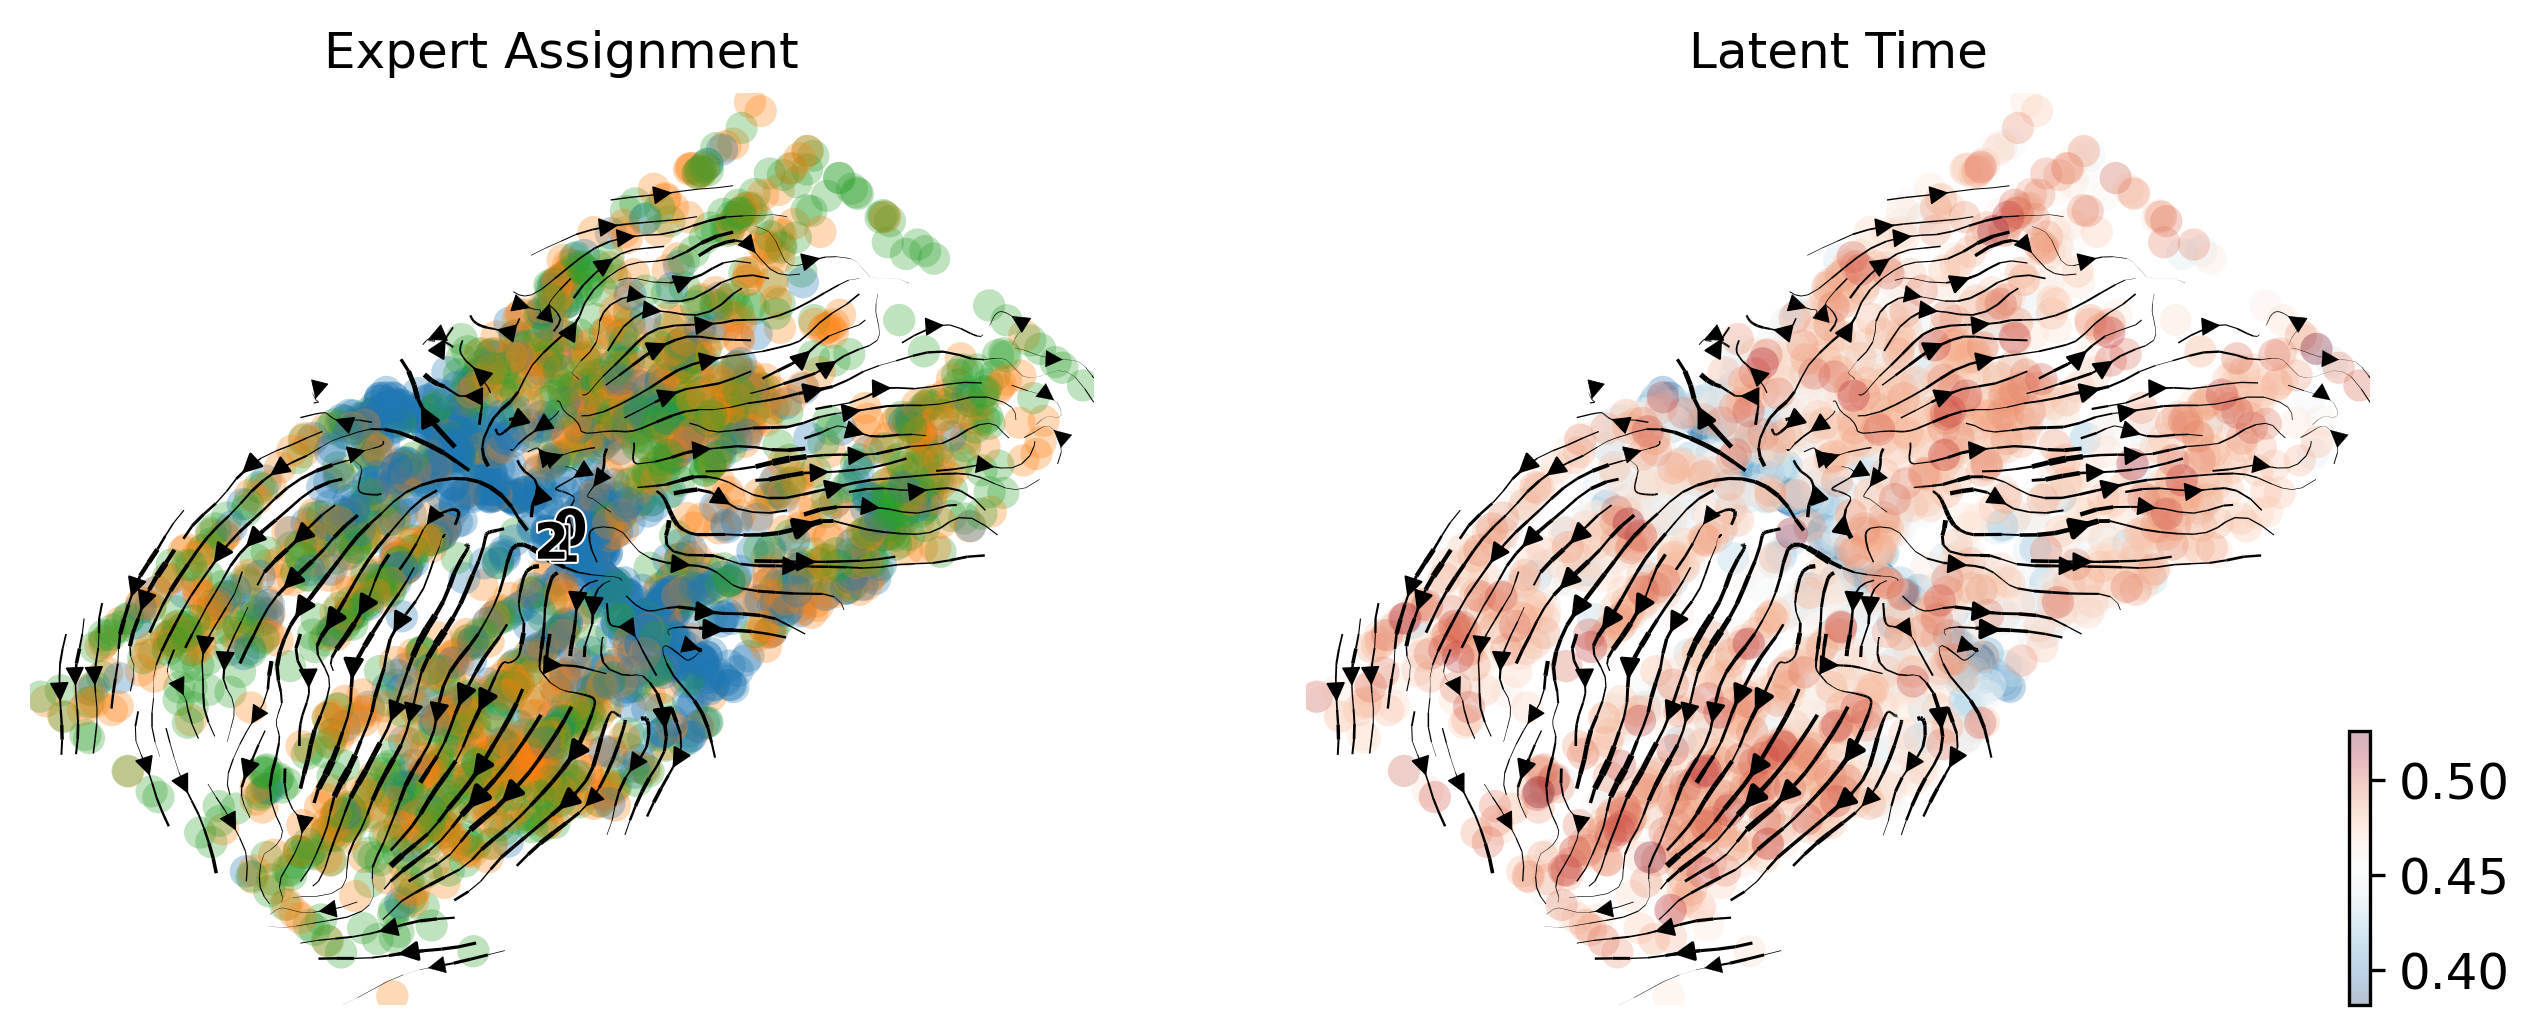

In [14]:
scv.settings.figdir = RESULT_PATH
scv.set_figure_params(style="scvelo", dpi=150, figsize=(5, 4), transparent=True)

scv.pl.velocity_embedding_stream(
    result_adata,
    basis="spatial",
    vkey="pred_vs_norm",
    color=["Expert", "Pred Time"],
    title=["Expert Assignment", "Latent Time"],
    show=True,
)


## Optional: PCA/UMAP Of The Learned Latent Embedding

`X_refine_embed` is the learned latent representation returned by the kinetic-learning stage. If you want a 2D view of that latent space, compute it explicitly here.

Set `USE_PCA_BEFORE_UMAP = True` if you want to apply PCA before building the UMAP graph.


In [15]:
USE_PCA_BEFORE_UMAP = True

result_adata = steer.compute_embedding_umap(
    result_adata,
    embedding_key="X_refine_embed",
    output_key="X_umap_refine_embed",
    pca_output_key="X_pca_refine_embed",
    neighbors_key="refine_embed_neighbors",
    n_neighbors=100,
    use_pca=USE_PCA_BEFORE_UMAP,
    n_pcs=cfg.npc,
    random_state=cfg.seed,
)


## Optional: Latent-Space Visualization

After computing `X_pca_refine_embed/X_umap_refine_embed`, you can inspect the learned latent structure in 2D and compare it with the spatial view above.


computing velocity embedding
    finished (0:00:00) --> added
    'pred_vs_norm_pca_refine_embed', embedded velocity vectors (adata.obsm)


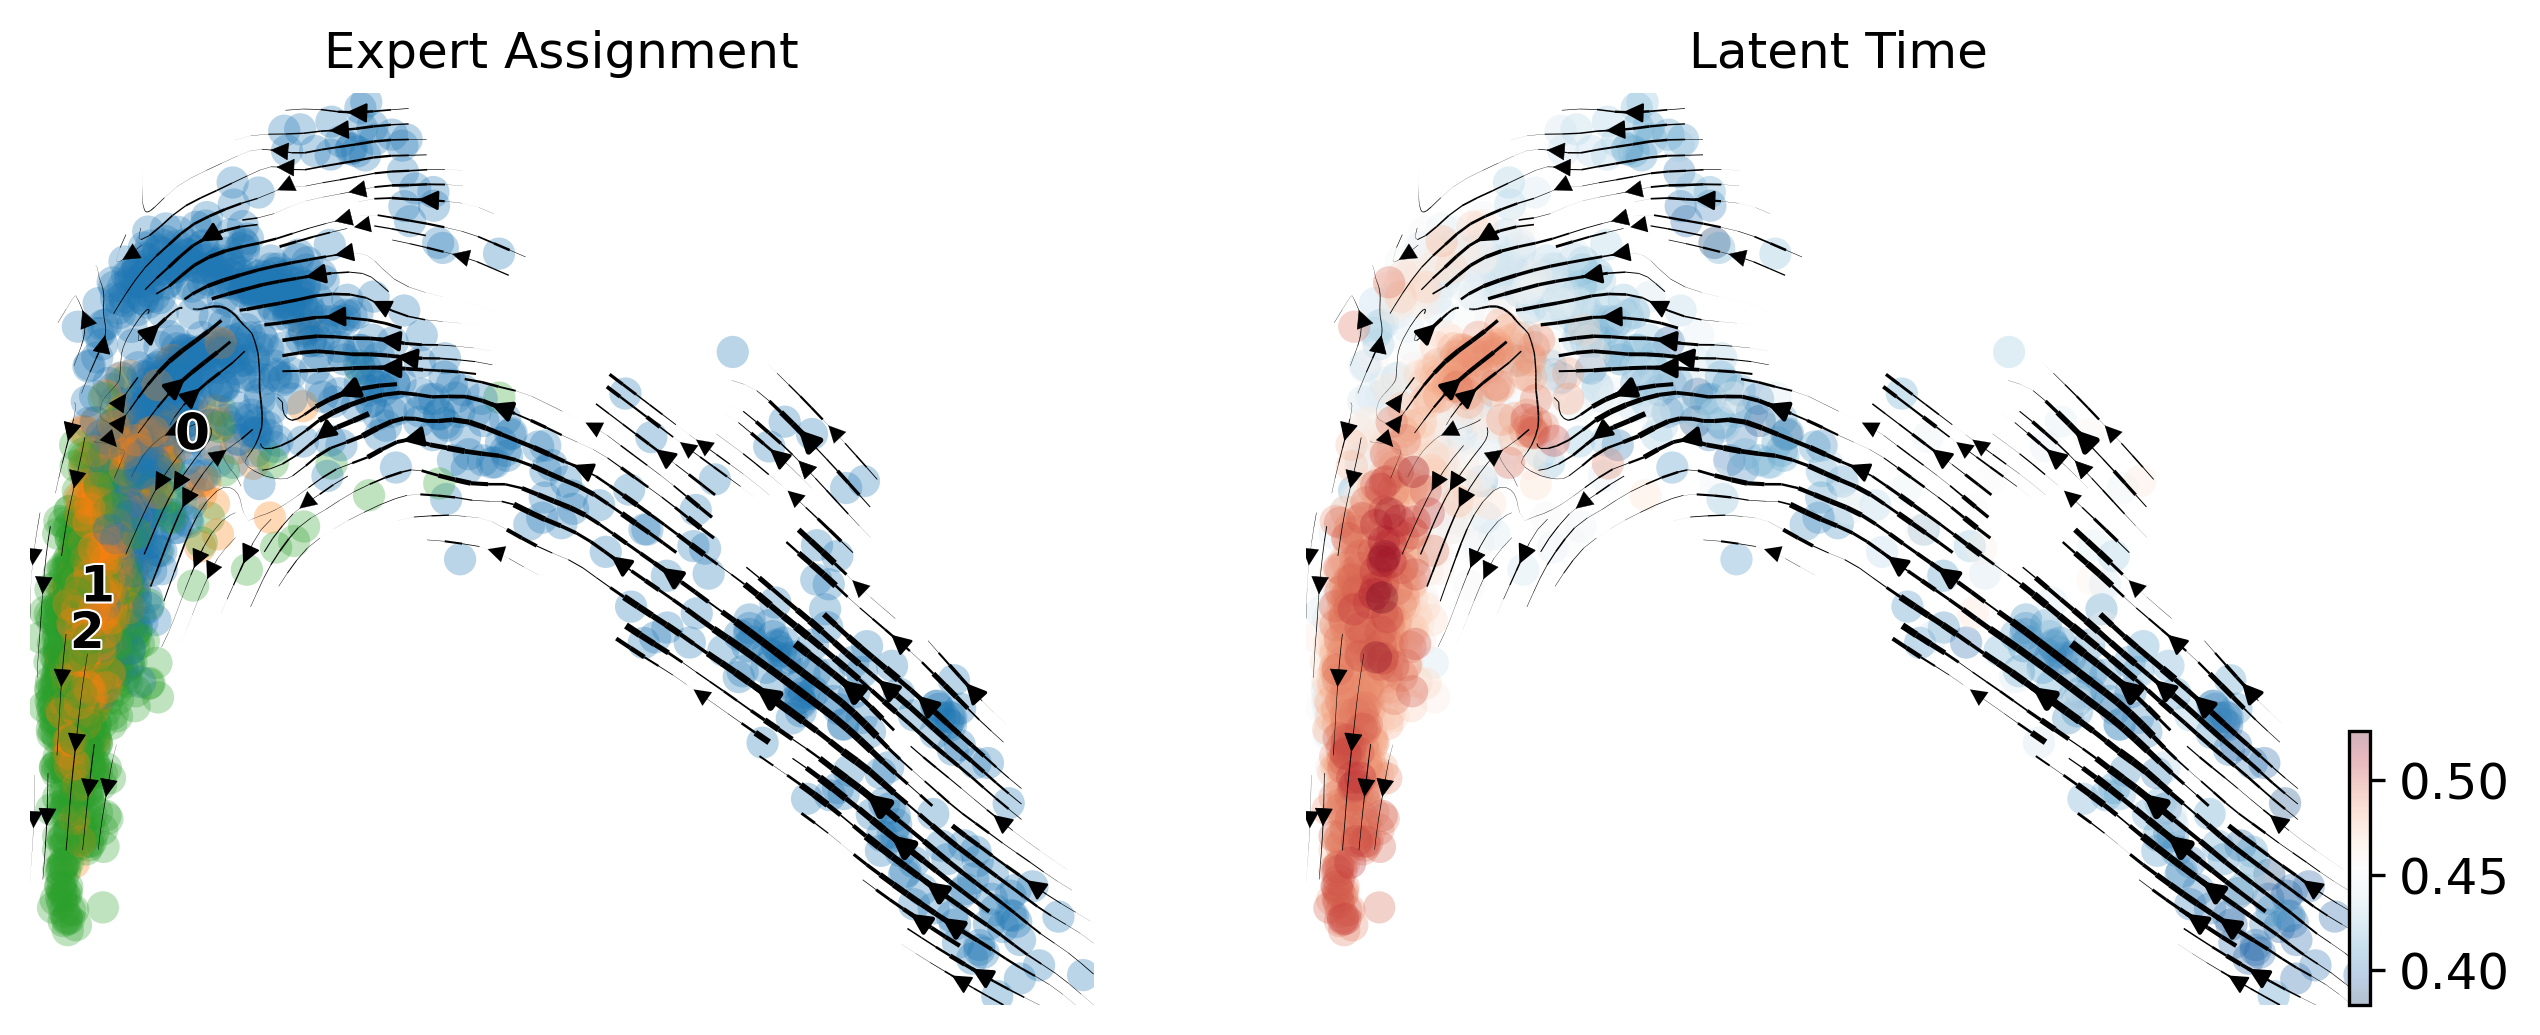

In [17]:
scv.pl.velocity_embedding_stream(
    result_adata,
    basis="X_pca_refine_embed",
    vkey="pred_vs_norm",
    color=["Expert", "Pred Time"],
    title=["Expert Assignment", "Latent Time"],
    show=True,
)


## Common Notes

- If `mclust` is unavailable, the notebook can still run, but the optional clustering step will be skipped.
- If you encounter installation issues, check the package versions for PyTorch, PyG, `torch-scatter`, and `torch-sparse` first.
- If you want to use your own data, the easiest path is to replace the demo `.h5ad` with a file that already contains `spliced`, `unspliced`, and spatial coordinates.